# Giai đoạn 5: Trực quan hóa dữ liệu (Visualization)
Dựa trên kết quả phân cụm đa chiều ở các bước trước, notebook này thực hiện trực quan hóa các cụm nghề nghiệp nhằm trích xuất các insight kinh doanh giá trị.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../plots', exist_ok=True)

# Thiết lập font tiếng Việt và style cho Seaborn
plt.rcParams['font.family'] = 'Arial'
sns.set_theme(style="whitegrid", palette="muted")
# Đọc dữ liệu đã phân cụm
df_train = pd.read_csv('../results/clean_data_train_clustered.csv')
print(f"Data shape: {df_train.shape}")
display(df_train[['job_title', 'cluster_label']].head(3))

Data shape: (523972, 26)


,job_title,cluster_label
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,Cụm 07: Chuyên viên Kế toán / Kiểm toán | Lươn...
1,kỹ sư giám sát xây dựng,Cụm 07: Chuyên viên Kế toán / Kiểm toán | Lươn...
2,tuyển sales telesales cho công ty bhnt prudential,Cụm 04: Thực tập sinh / Fresher | Lương ~9M | ...


## 1. Thị phần các cụm nghề nghiệp (Cluster Proportions)

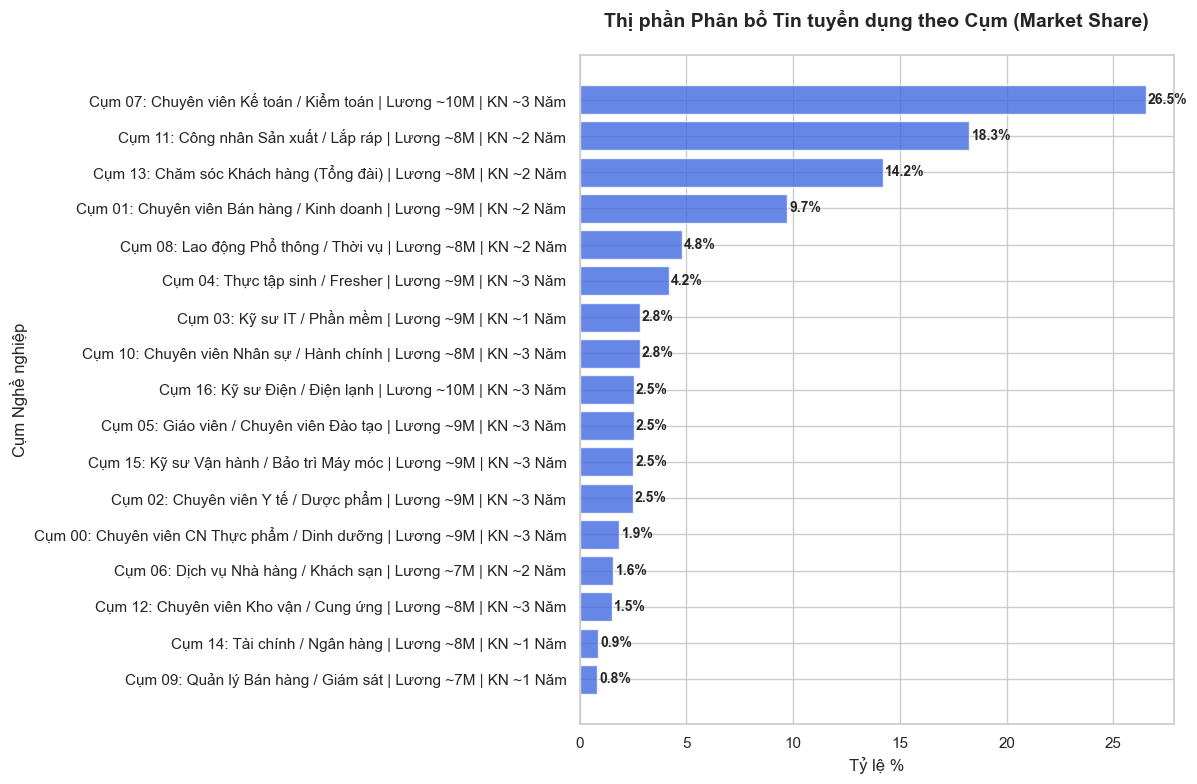

In [20]:
plt.figure(figsize=(12, 8))
cluster_counts = df_train['cluster_label'].value_counts(ascending=True)
pct = cluster_counts / len(df_train) * 100

bars = plt.barh(cluster_counts.index, pct, color='royalblue', alpha=0.8)
plt.title('Thị phần Phân bổ Tin tuyển dụng theo Cụm (Market Share)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ %', fontsize=12)
plt.ylabel('Cụm Nghề nghiệp', fontsize=12)

# Thêm text %
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/05_market_share.png', dpi=150)
plt.show()

## 2. Bản đồ Định vị Giá trị (Lương vs Kinh nghiệm)

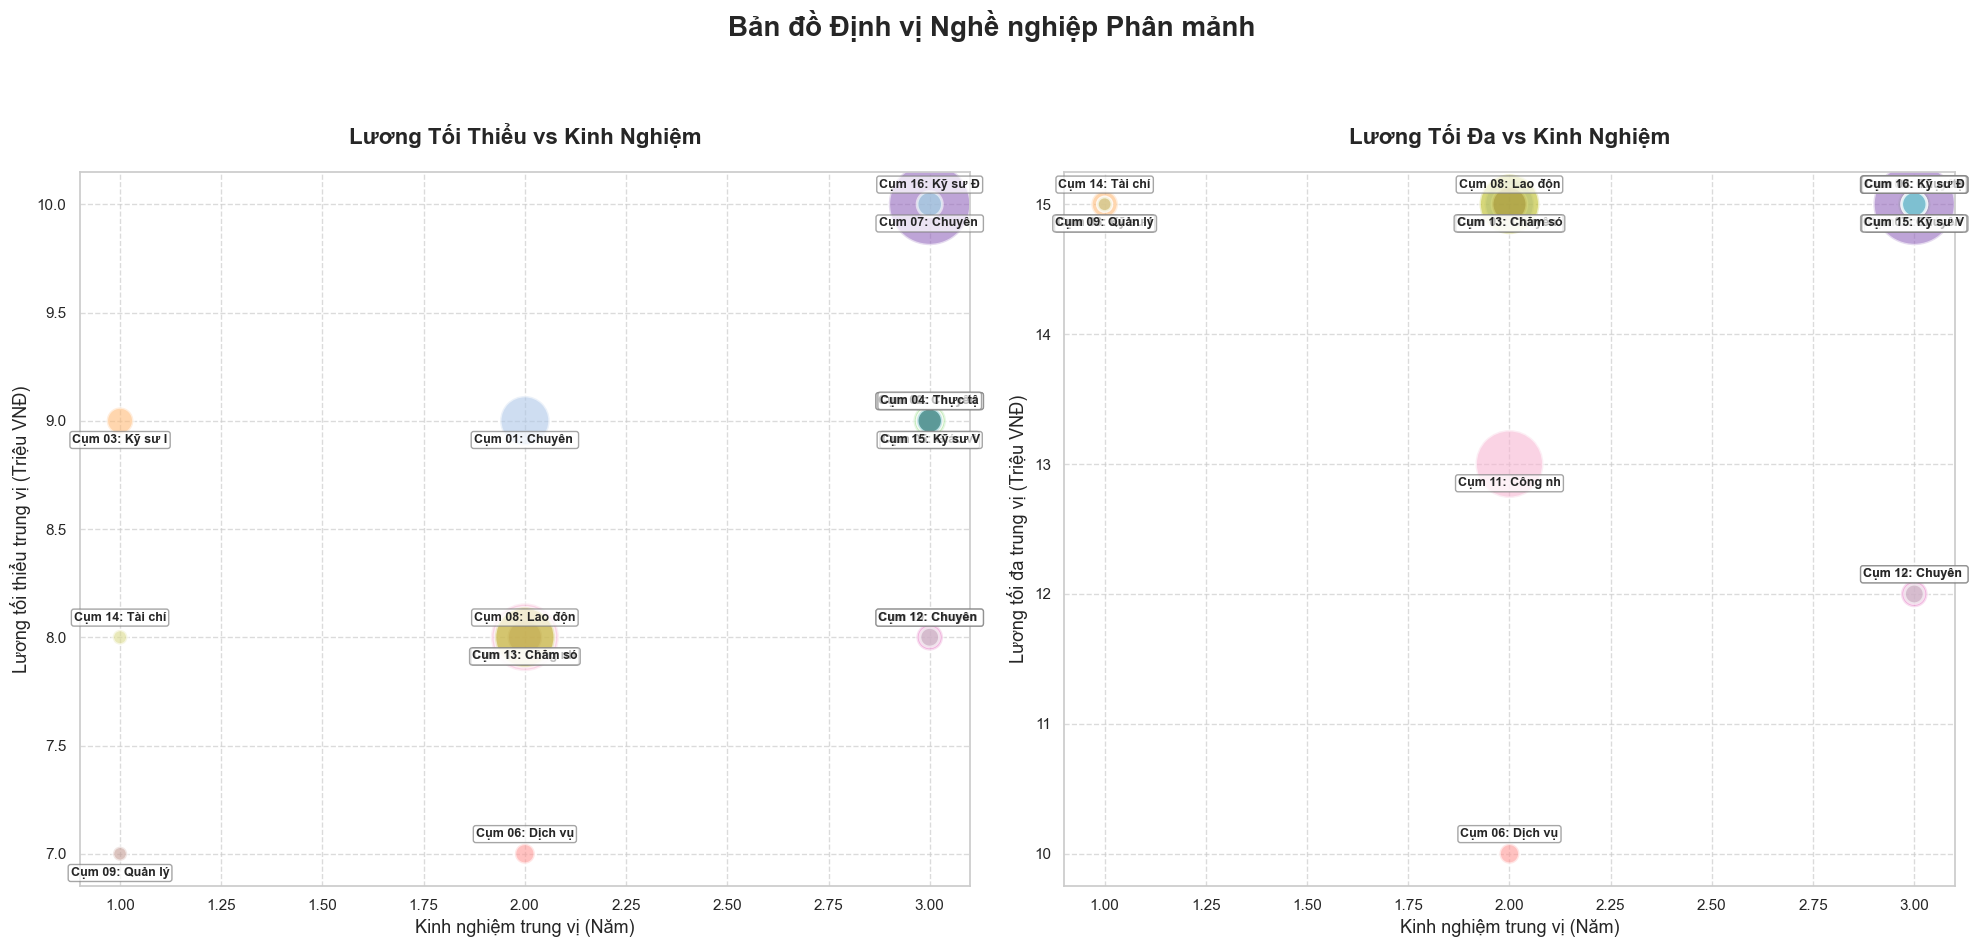

In [21]:
# Tính trung vị lương (min, max) và kinh nghiệm cho mỗi cụm
cluster_profiles = df_train.groupby('cluster_label').agg(
    salary_min_med=('salary_min_m_vnd', 'median'),
    salary_max_med=('salary_max_m_vnd', 'median'),
    exp_med=('exp_min_years', 'median'),
    size=('cluster_id', 'count')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Hàm hỗ trợ vẽ và gắn nhãn
def plot_scatter(ax, x_col, y_col, title, ylabel):
    scatter = ax.scatter(x=cluster_profiles[x_col], 
                y=cluster_profiles[y_col], 
                s=cluster_profiles['size'] / 40,  # Scale bong bóng
                alpha=0.6, 
                c=range(len(cluster_profiles)), cmap='tab20', edgecolors='white', linewidth=2)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Kinh nghiệm trung vị (Năm)', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    
    # Gắn nhãn, thêm một chút nhiễu (offset) để giảm chồng lấn
    for i, row in cluster_profiles.iterrows():
        short_name = row['cluster_label'].split('-')[1].strip() if '-' in row['cluster_label'] else row['cluster_label'][:15]
        # Nếu các điểm có cùng tọa độ x, dịch y lên/xuống luân phiên
        offset_y = 12 if i % 2 == 0 else -16 # type: ignore
        ax.annotate(short_name, 
                     (row[x_col], row[y_col]),
                     xytext=(0, offset_y), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7))
    
    ax.grid(True, linestyle='--', alpha=0.7)

# Subplot 1: Min Salary
plot_scatter(ax1, 'exp_med', 'salary_min_med', 'Lương Tối Thiểu vs Kinh Nghiệm', 'Lương tối thiểu trung vị (Triệu VNĐ)')

# Subplot 2: Max Salary
plot_scatter(ax2, 'exp_med', 'salary_max_med', 'Lương Tối Đa vs Kinh Nghiệm', 'Lương tối đa trung vị (Triệu VNĐ)')

plt.suptitle('Bản đồ Định vị Nghề nghiệp Phân mảnh', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../plots/05_value_position_map_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Phổ dao động lương theo cụm (Boxplot)

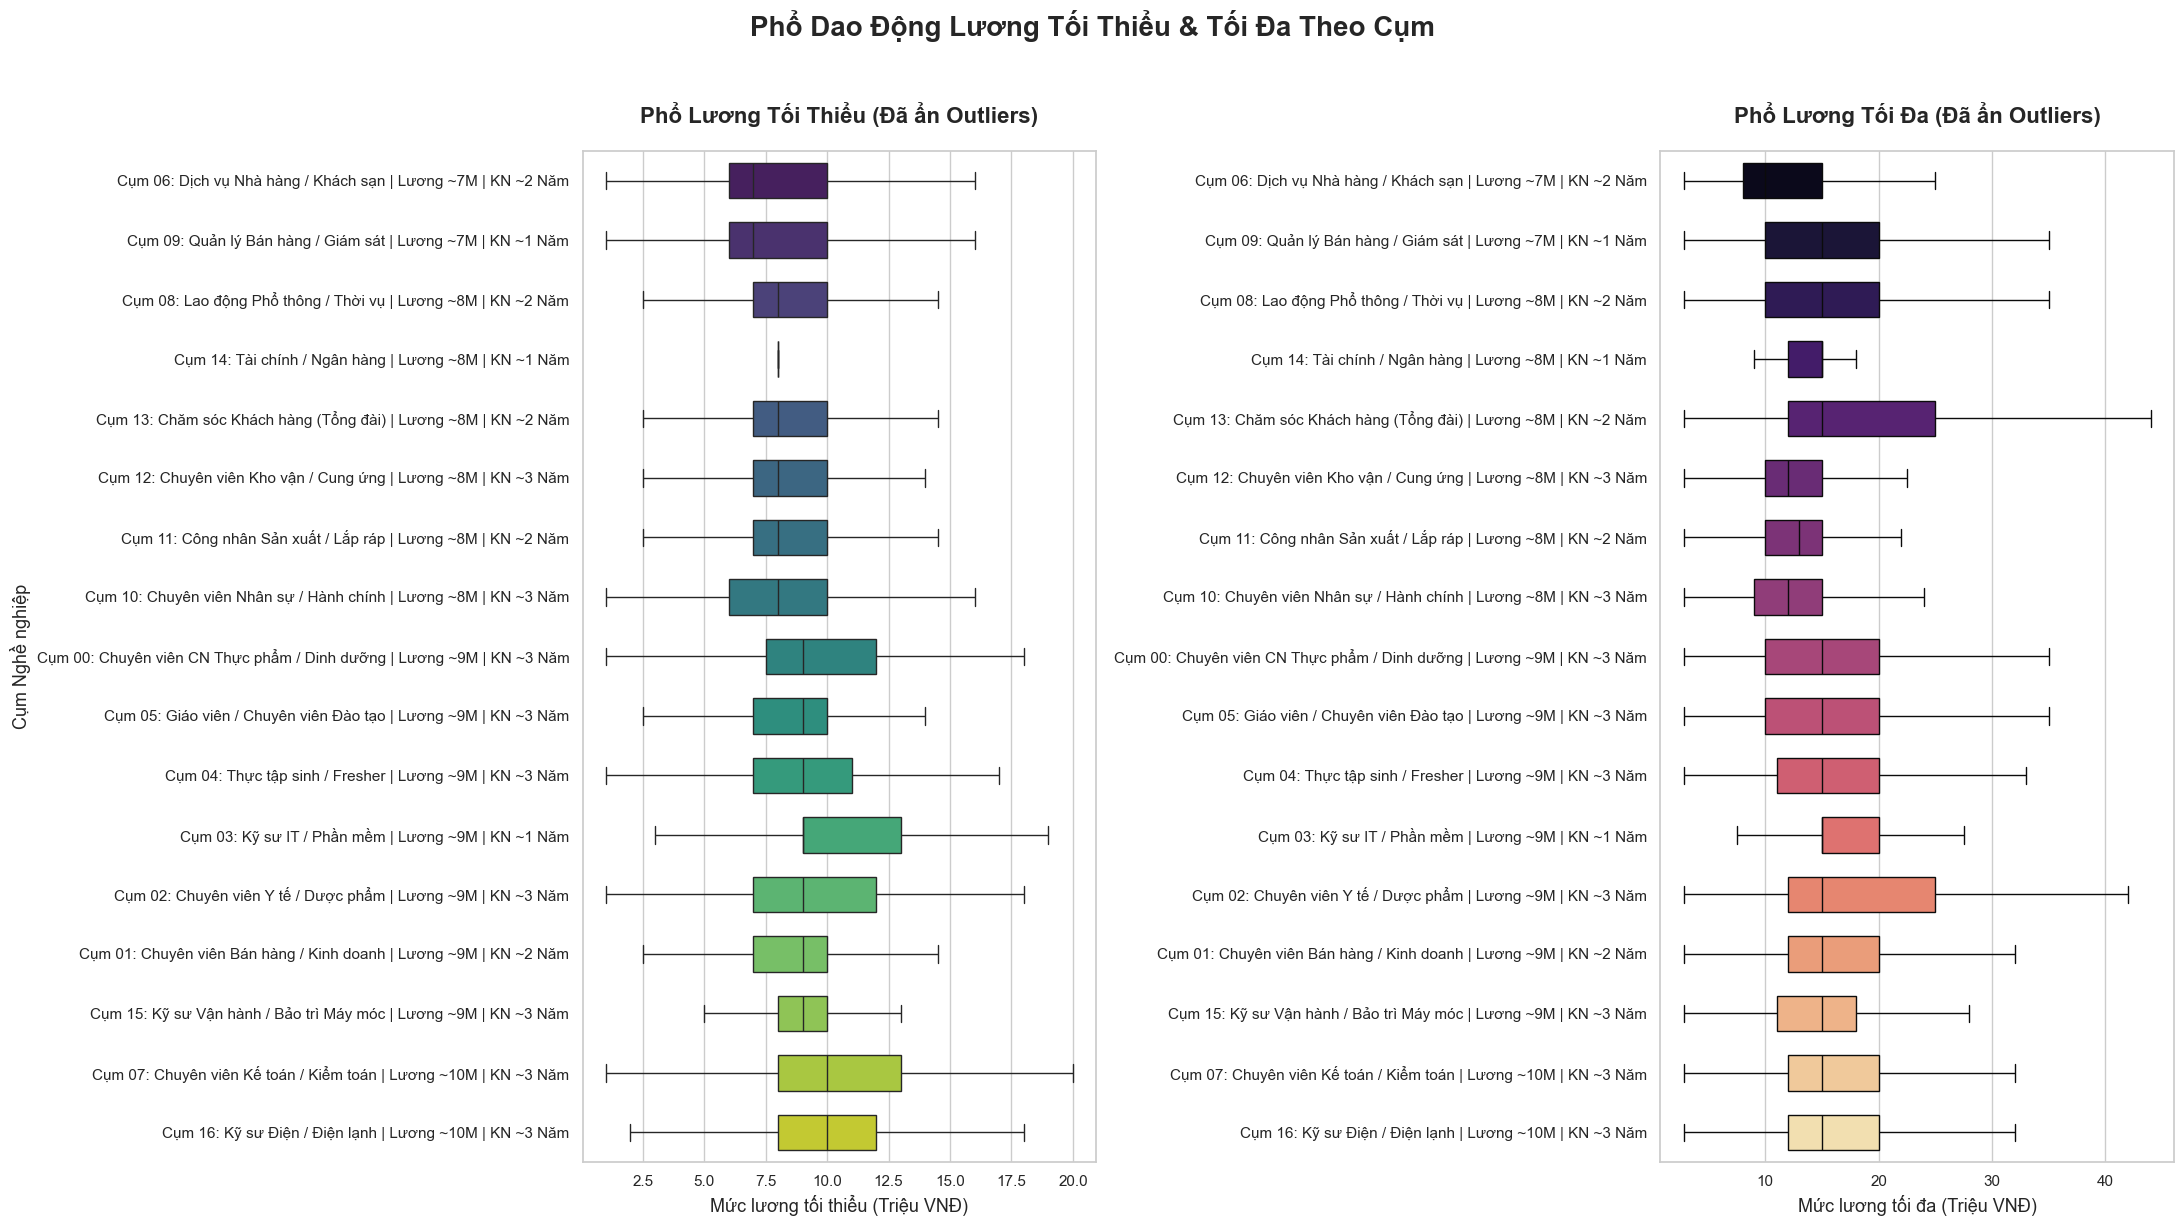

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 12))

# Sắp xếp các cụm theo mức lương trung vị tối thiểu tăng dần để dễ nhìn
order = cluster_profiles.sort_values('salary_min_med')['cluster_label']

# Subplot 1: Lương tối thiểu
sns.boxplot(data=df_train, x='salary_min_m_vnd', y='cluster_label', order=order, 
            palette='viridis', showfliers=False, width=0.6, ax=ax1)
ax1.set_title('Phổ Lương Tối Thiểu (Đã ẩn Outliers)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Mức lương tối thiểu (Triệu VNĐ)', fontsize=13)
ax1.set_ylabel('Cụm Nghề nghiệp', fontsize=13)

# Subplot 2: Lương tối đa
sns.boxplot(data=df_train, x='salary_max_m_vnd', y='cluster_label', order=order, 
            palette='magma', showfliers=False, width=0.6, ax=ax2)
ax2.set_title('Phổ Lương Tối Đa (Đã ẩn Outliers)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Mức lương tối đa (Triệu VNĐ)', fontsize=13)
ax2.set_ylabel('')  # Ẩn nhãn trục Y ở biểu đồ thứ 2 để tránh lặp lại

plt.suptitle('Phổ Dao Động Lương Tối Thiểu & Tối Đa Theo Cụm', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/05_salary_distribution_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Trực quan hóa ranh giới hình học bằng PCA (2D Projection)

In [24]:
from sklearn.decomposition import PCA
import plotly.express as px

print("Loading 169D features...")
train_data = np.load("../results/features_train.npz")
X_train = train_data["features_169d"]
labels = df_train['cluster_id'].values
labels_text = df_train['cluster_label'].values

# Lấy mẫu 10,000 điểm để chạy PCA nhanh và biểu đồ không bị rối
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), 10000, replace=False)
X_sample = X_train[sample_idx]
labels_sample = labels_text[sample_idx]  # Hiển thị tên cụm thay vì số ID

print("Running PCA projection to 3D...")
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Cụm Nghề nghiệp': labels_sample
})

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
              color='Cụm Nghề nghiệp',
              opacity=0.6,
              title='Bản đồ Phân mảnh Không gian Cụm (PCA 3D Projection)',
              color_discrete_sequence=px.colors.qualitative.Alphabet)

fig.update_traces(marker=dict(size=3))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.write_html('../plots/05_pca_clusters_3d.html')
fig.show()
print("Visualization phase complete! 3D plot saved as HTML.")

Loading 169D features...
Running PCA projection to 3D...


Visualization phase complete! 3D plot saved as HTML.
